## Bussiness Questions

1. Brand apa yang paling populer di Indonesia?
2. Produk apa yang paling banyak direview?
3. Produk apa yang ratingnya tinggi?
4. Kategori skincare apa yang paling populer?

In [4]:
import pandas as pd

df = pd.read_csv("Indonesian_Skincare.csv")

print(df.columns)
print(df.head())
print(df.info())

Index(['Type', 'Name', 'Brand', 'Rating', 'Total Reviewers', 'Link'], dtype='object')
        Type                                             Name  \
0  Sunscreen                      Sun Protection SPF 30 PA+++   
1  Sunscreen              Hydrasoothe Sunscreen Gel SPF 45+++   
2  Sunscreen                                 UV Moisture Milk   
3  Sunscreen  UV Shield Essential Sunscreen Gel SPF 35 PA +++   
4  Sunscreen       UV Aqua Rich Watery Essence SPF 50+/PA++++   

               Brand  Rating Total Reviewers  \
0              Emina     3.6          13,700   
1  Azarine Cosmetics     4.1           9,441   
2          Skin Aqua     4.2           8,947   
3             Wardah     3.3           8,358   
4              Biore     4.2           7,362   

                                                Link  
0  https://reviews.femaledaily.com/products/moist...  
1  https://reviews.femaledaily.com/products/moist...  
2  https://reviews.femaledaily.com/products/moist...  
3  https://rev

## Data Cleaning


In [5]:
df.isnull().sum()

,0
Type,0
Name,0
Brand,0
Rating,0
Total Reviewers,0
Link,0


In [6]:
df.duplicated().sum()

np.int64(2)

In [7]:
df["Total Reviewers"] = (
    df["Total Reviewers"]
    .str.replace(",", "")
    .astype(int)
)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7432 entries, 0 to 7431
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             7432 non-null   object 
 1   Name             7432 non-null   object 
 2   Brand            7432 non-null   object 
 3   Rating           7432 non-null   float64
 4   Total Reviewers  7432 non-null   int64  
 5   Link             7432 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 348.5+ KB


### EDA 1 - Distribusi Jenis Produk Skincare

Tujuan Analisis :

Menganalisis jenis produk skincare yang paling banyak muncul dalam dataset Female Daily untuk mengetahui kategori produk yang paling populer di kalangan pengguna.

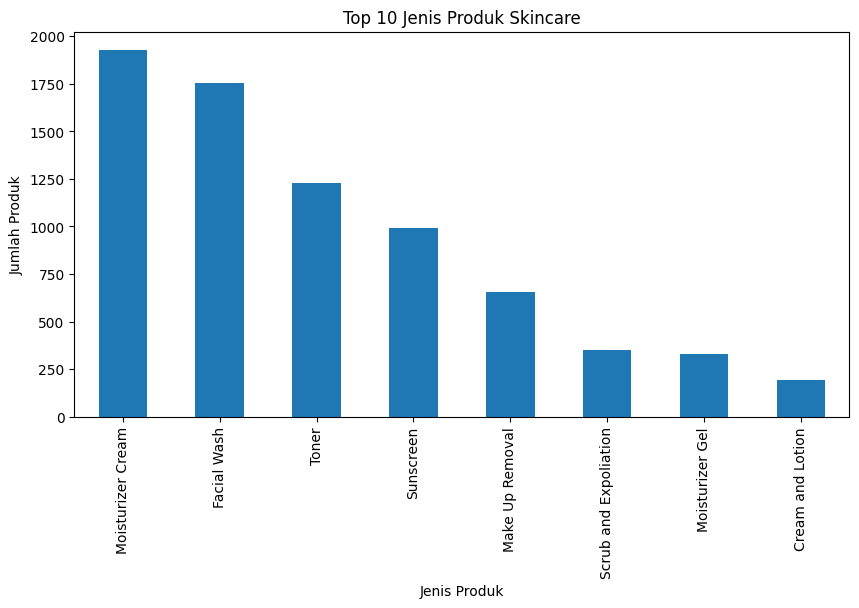

In [11]:
type_counts = df["Type"].value_counts()

plt.figure(figsize=(10,5))
type_counts.head(10).plot(kind="bar")

plt.title("Top 10 Jenis Produk Skincare")
plt.xlabel("Jenis Produk")
plt.ylabel("Jumlah Produk")

plt.show()

## Insight :

Berdasarkan hasil visualisasi, beberapa jenis produk skincare mendominasi dataset Female Daily. Hal ini menunjukkan bahwa kategori produk tersebut memiliki tingkat penggunaan dan perhatian yang tinggi dari pengguna skincare Indonesia. Informasi ini dapat dimanfaatkan oleh LumiSkin untuk memprioritaskan kategori produk yang paling relevan dalam sistem rekomendasi.

## EDA 2 - Brand Skincare yang Paling Banyak Muncul


Tujuan Analisis :

Menganalisis brand skincare yang memiliki jumlah produk terbanyak dalam dataset Female Daily.

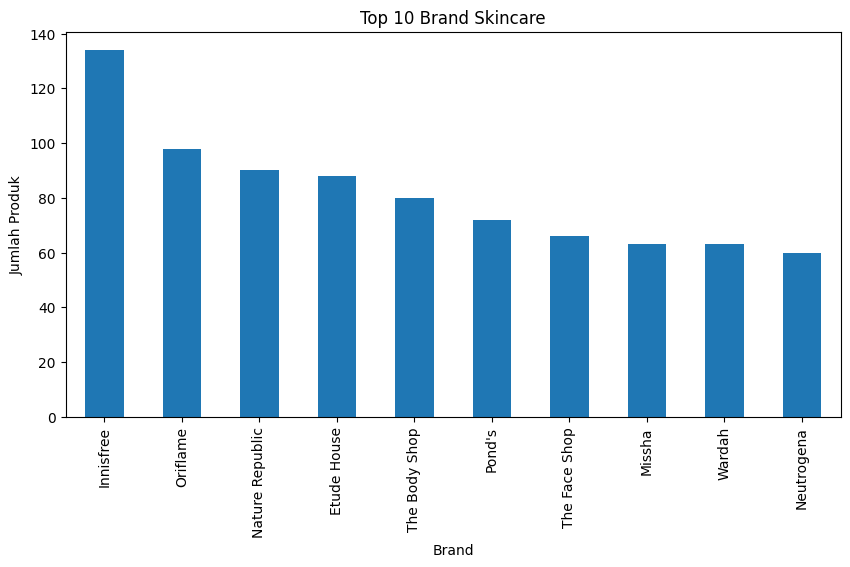

In [12]:
brand_counts = df["Brand"].value_counts()

plt.figure(figsize=(10,5))
brand_counts.head(10).plot(kind="bar")

plt.title("Top 10 Brand Skincare")
plt.xlabel("Brand")
plt.ylabel("Jumlah Produk")

plt.show()

## Insight :

Beberapa brand memiliki jumlah produk yang lebih banyak dibandingkan brand lainnya. Hal ini menunjukkan bahwa brand tersebut memiliki variasi produk yang luas dan aktif di pasar skincare Indonesia. Brand dengan jumlah produk yang tinggi berpotensi menjadi kandidat utama dalam sistem rekomendasi LumiSkin.

## EDA 3 - Produk dengan Jumlah Reviewer Terbanyak


Tujuan Analisis :

Mengidentifikasi produk skincare yang memiliki jumlah reviewer terbanyak sebagai indikator popularitas produk.

In [13]:
top_reviewed = df.nlargest(
    10,
    "Total Reviewers"
)[["Brand", "Name", "Total Reviewers"]]

top_reviewed

,Brand,Name,Total Reviewers
6779,Garnier,Micellar Cleansing Water All-in-1,14100
0,Emina,Sun Protection SPF 30 PA+++,13700
991,Cetaphil,Gentle Skin Cleanser,13200
1,Azarine Cosmetics,Hydrasoothe Sunscreen Gel SPF 45+++,9441
6780,Pond's,Vitamin Micellar Water,9389
2,Skin Aqua,UV Moisture Milk,8947
3,Wardah,UV Shield Essential Sunscreen Gel SPF 35 PA +++,8358
4,Biore,UV Aqua Rich Watery Essence SPF 50+/PA++++,7362
992,Senka,Perfect Whip Facial Foam,5300
5005,Hada Labo,Gokujyun Ultimate Moisturizing Lotion,5269


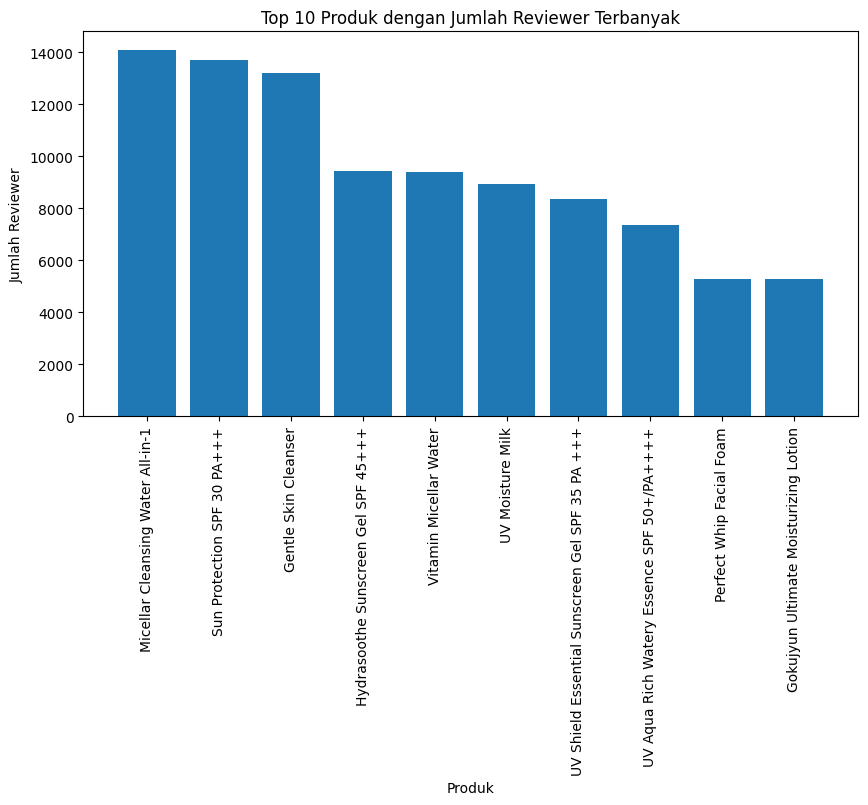

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    top_reviewed["Name"],
    top_reviewed["Total Reviewers"]
)

plt.title("Top 10 Produk dengan Jumlah Reviewer Terbanyak")
plt.xlabel("Produk")
plt.ylabel("Jumlah Reviewer")

plt.xticks(rotation=90)

plt.show()

## Insight :

Produk dengan jumlah reviewer yang tinggi menunjukkan tingkat popularitas dan keterlibatan pengguna yang besar. Produk-produk ini dapat dijadikan referensi utama dalam sistem rekomendasi karena telah digunakan dan dinilai oleh banyak pengguna.

## EDA 4 - Produk dengan Rating Tertinggi


Tujuan Analisis :

Mengidentifikasi produk skincare dengan rating tertinggi berdasarkan ulasan pengguna.

In [15]:
top_rating = df.nlargest(
    10,
    "Rating"
)[["Brand", "Name", "Rating"]]

top_rating

,Brand,Name,Rating
124,Zamron,Brightening Sunscreen,5.0
147,eBright Skin,Sunscreen Cream,5.0
174,Mirelle,Acne UV,5.0
210,Hedtutu,Antioxydant Sunscreen,5.0
274,drvit,Sunblock Kuning,5.0
285,Aceskin,Daily Face Sunscreen SPF 30 PA ++,5.0
327,YOU Beauty,Sunbrella Airy Outdoor Sunscreen Spray SPF 50+...,5.0
342,Round Lab,Birch Juice Moisturizing Sun Cream,5.0
371,dr Ekle's Skincare,Oxy Glow Sun Protection,5.0
420,EltaMD,UV CLEAR BROAD SPECTRUM SPF 46,5.0


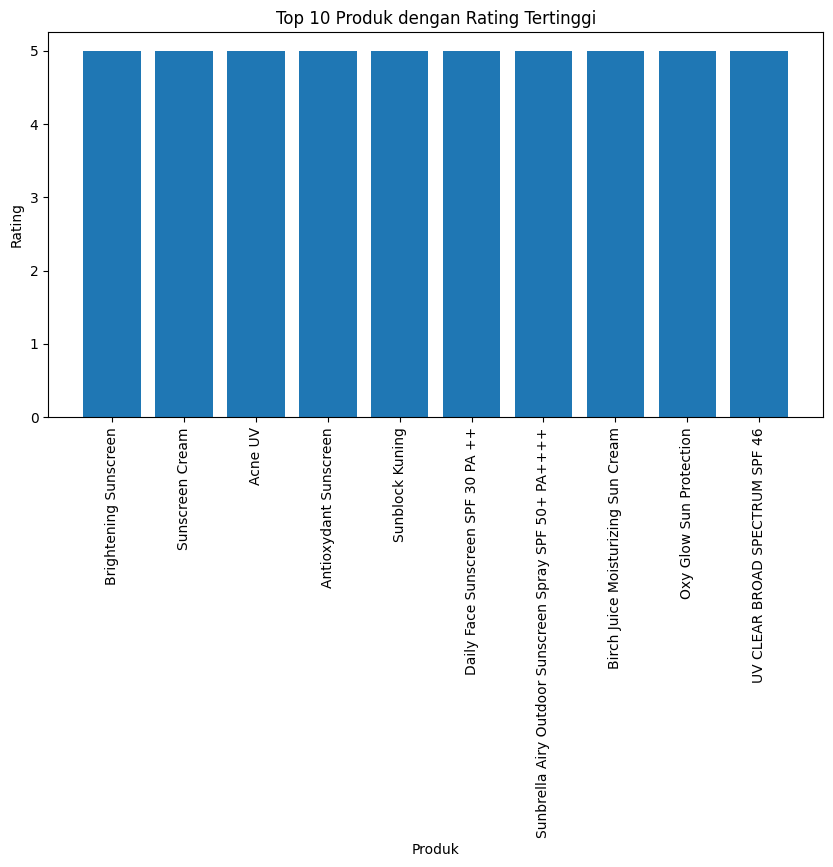

In [16]:
plt.figure(figsize=(10,5))

plt.bar(
    top_rating["Name"],
    top_rating["Rating"]
)

plt.title("Top 10 Produk dengan Rating Tertinggi")
plt.xlabel("Produk")
plt.ylabel("Rating")

plt.xticks(rotation=90)

plt.show()

## Insight :

Produk dengan rating tinggi menunjukkan tingkat kepuasan pengguna yang baik. Namun jumlah reviewer juga perlu diperhatikan agar rating yang diperoleh benar-benar representatif.

## EDA 5 - Distribusi Rating Produk


Tujuan Analisis :

Menganalisis persebaran rating produk skincare dalam dataset Female Daily.

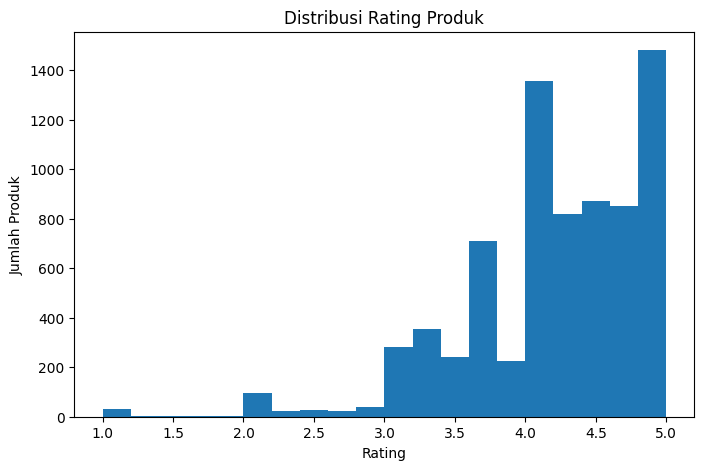

In [17]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Rating"],
    bins=20
)

plt.title("Distribusi Rating Produk")
plt.xlabel("Rating")
plt.ylabel("Jumlah Produk")

plt.show()

## Insight :

Sebagian besar produk memiliki rating pada rentang menengah hingga tinggi. Hal ini menunjukkan bahwa mayoritas produk skincare dalam dataset memperoleh tanggapan positif dari pengguna Female Daily.

## Kesimpulan

Berdasarkan hasil analisis, beberapa kategori produk dan brand mendominasi dataset Female Daily. Produk dengan jumlah reviewer yang tinggi menunjukkan tingkat popularitas yang besar, sedangkan produk dengan rating tinggi menunjukkan tingkat kepuasan pengguna yang baik. Secara keseluruhan, dataset ini dapat dimanfaatkan untuk mendukung pengembangan sistem rekomendasi skincare yang lebih relevan bagi pengguna Indonesia dalam aplikasi LumiSkin.

## Data Dictionary

| Kolom           | Deskripsi                              |
| --------------- | -------------------------------------- |
| Type            | Jenis produk skincare                  |
| Name            | Nama produk                            |
| Brand           | Nama merek produk                      |
| Rating          | Nilai rating produk                    |
| Total Reviewers | Jumlah pengguna yang memberikan ulasan |
| Link            | URL halaman produk Female Daily        |